In [3]:
import pandas as pd
from database import get_engine

def time_to_seconds(timestr):
    """Convert a time string (HH:MM:SS or MM:SS or SS) to seconds (int). Handles None/NaN."""
    if pd.isna(timestr) or timestr is None:
        return None
    if isinstance(timestr, (int, float)):
        return int(timestr)
    parts = str(timestr).split(":")
    try:
        if len(parts) == 3:
            h, m, s = [int(float(p)) for p in parts]
            return h*3600 + m*60 + s
        elif len(parts) == 2:
            m, s = [int(float(p)) for p in parts]
            return m*60 + s
        elif len(parts) == 1:
            return int(float(parts[0]))
    except Exception:
        return None
    return None

def seconds_to_hms(seconds):
    """Convert seconds (int) to MM:SS string, preserving sign for negatives."""
    if pd.isna(seconds):
        return None
    sign = "-" if seconds < 0 else ""
    seconds = abs(int(round(seconds)))
    m = (seconds % 3600) // 60
    s = seconds % 60
    return f"{sign}{m:02}:{s:02}"

def h2h_summary(athletes, events) -> pd.DataFrame: 
  engine = get_engine()
  # Load race_results (for position) and position_metrics (for elapsedrun)
  df = pd.read_sql("""
      SELECT
        rr.event_id,
        rr.athlete_id,
        rr.prog_id,
        rr.position,
        rr.swimtime,
        rr.t1time, 
        rr.biketime,
        rr.t2time,
        rr.runtime,
        pm.elapsedrun 
      FROM race_results rr
      LEFT JOIN position_metrics pm
        ON rr.event_id = pm.event_id AND rr.athlete_id = pm.athlete_id AND rr.prog_id = pm.prog_id
  """, engine)

  # Convert segment times to seconds
  for col in ['swimtime','t1time','biketime','t2time','runtime']:
      df[col + '_sec'] = df[col].apply(time_to_seconds)

  # Load split rankings from position_metrics and merge with race_results
  df_metrics = pd.read_sql("""
      SELECT
        event_id,
        athlete_id,
        prog_id,
        swimrank,
        t1rank,
        bikerank,
        t2rank,
        runrank
      FROM position_metrics
  """, engine)

  # Merge split rankings into main race results DataFrame
  df = df.merge(df_metrics, on=["event_id", "athlete_id", "prog_id"], how="left")

  # Load athlete full names and join to df
  df_athletes = pd.read_sql("SELECT athlete_id, full_name FROM athlete", engine)
  df_events = pd.read_sql("SELECT event_id, event_name, prog_id, prog_name FROM events", engine)
  df = df.merge(df_athletes, on="athlete_id", how="left")
  df = df.merge(df_events[['event_id', 'prog_id', 'prog_name']], on=['event_id', 'prog_id'], how='left')
  df = df[df['prog_name'] != "Mixed Relay"]

  # ----- FILTERING ------  
  athlete_ids = df_athletes[df_athletes['full_name'].isin(athletes)]['athlete_id'].tolist()
  df = df[df['athlete_id'].isin(athlete_ids)]
  event_ids = df_events[df_events['event_name'].isin(events)]['event_id'].tolist()
  df = df[df['event_id'].isin(event_ids)]

  # create every A vs B in the same event/program
  df_pairs = (
    df.merge(df, on=["prog_id"], suffixes=("_a", "_b"))
      .query("athlete_id_a < athlete_id_b")  # unordered pairs only once
)

  # Win flags for overall and each segment (renamed to match h2h_summary table)
  df_pairs["wins_a"]         = df_pairs["position_a"]   < df_pairs["position_b"]
  df_pairs["swim_wins_a"]    = df_pairs["swimrank_a"]    < df_pairs["swimrank_b"]
  df_pairs["t1_wins_a"]      = df_pairs["t1rank_a"]      < df_pairs["t1rank_b"]
  df_pairs["bike_wins_a"]    = df_pairs["bikerank_a"]    < df_pairs["bikerank_b"]
  df_pairs["t2_wins_a"]      = df_pairs["t2rank_a"]      < df_pairs["t2rank_b"]
  df_pairs["run_wins_a"]     = df_pairs["runrank_a"]     < df_pairs["runrank_b"]

  # --- Average Time Gap (elapsedrun) ---
  df_pairs["time_diff_sec"] = df_pairs["elapsedrun_a"] - df_pairs["elapsedrun_b"]

  # --- Segment time differences ---
  for seg in ['swimtime_sec','t1time_sec','biketime_sec','t2time_sec','runtime_sec']:
      df_pairs[f'{seg}_diff'] = df_pairs[f'{seg}_a'] - df_pairs[f'{seg}_b']

  # Aggregate H2H metrics by athlete pair
  agg_dict = {
      "matches": ("prog_id", "count"),
      "wins_a": ("wins_a", "sum"),
      "swim_wins_a": ("swim_wins_a", "sum"),
      "t1_wins_a": ("t1_wins_a", "sum"),
      "bike_wins_a": ("bike_wins_a", "sum"),
      "t2_wins_a": ("t2_wins_a", "sum"),
      "run_wins_a": ("run_wins_a", "sum"),
      "avg_time_diff_sec": ("time_diff_sec", "mean"),
      "min_time_diff_sec": ("time_diff_sec", "min"),
      "max_time_diff_sec": ("time_diff_sec", "max"),
  }
  # Add segment avg diff columns
  for seg in ['swimtime_sec','t1time_sec','biketime_sec','t2time_sec','runtime_sec']:
      agg_dict[f'avg_{seg}_diff'] = (f'{seg}_diff', 'mean')
      agg_dict[f'min_{seg}_diff'] = (f'{seg}_diff', 'min')
      agg_dict[f'max_{seg}_diff'] = (f'{seg}_diff', 'max')

  h2h = (
    df_pairs
      .groupby(["athlete_id_a", "athlete_id_b"])
      .agg(**agg_dict)
      .reset_index()
)

  # Calculate win percentages (renamed to match h2h_summary)
  h2h["win_pct_a"]        = h2h["wins_a"]      / h2h["matches"]
  h2h["swim_win_pct_a"]  = h2h["swim_wins_a"] / h2h["matches"]
  h2h["t1_win_pct_a"]    = h2h["t1_wins_a"]   / h2h["matches"]
  h2h["bike_win_pct_a"]  = h2h["bike_wins_a"] / h2h["matches"]
  h2h["t2_win_pct_a"]    = h2h["t2_wins_a"]   / h2h["matches"]
  h2h["run_win_pct_a"]   = h2h["run_wins_a"]  / h2h["matches"]

  # Compute wins and win percentages for athlete B (renamed to match h2h_summary)
  h2h['wins_b']        = h2h['matches'] - h2h['wins_a']
  h2h['swim_wins_b']   = h2h['matches'] - h2h['swim_wins_a']
  h2h['t1_wins_b']     = h2h['matches'] - h2h['t1_wins_a']
  h2h['bike_wins_b']   = h2h['matches'] - h2h['bike_wins_a']
  h2h['t2_wins_b']     = h2h['matches'] - h2h['t2_wins_a']
  h2h['run_wins_b']    = h2h['matches'] - h2h['run_wins_a']

  # Compute win percentage for athlete B (renamed to match h2h_summary)
  h2h['win_pct_b']        = h2h['wins_b']      / h2h['matches']
  h2h['swim_win_pct_b']   = h2h['swim_wins_b'] / h2h['matches']
  h2h['t1_win_pct_b']     = h2h['t1_wins_b']   / h2h['matches']
  h2h['bike_win_pct_b']   = h2h['bike_wins_b'] / h2h['matches']
  h2h['t2_win_pct_b']     = h2h['t2_wins_b']   / h2h['matches']
  h2h['run_win_pct_b']    = h2h['run_wins_b']  / h2h['matches']

  # Map athlete_id to full_name for both athlete_id_a and athlete_id_b
  id_to_name = df_athletes.set_index('athlete_id')['full_name'].to_dict()
  h2h['athlete_name_a'] = h2h['athlete_id_a'].map(id_to_name)
  h2h['athlete_name_b'] = h2h['athlete_id_b'].map(id_to_name)

  # Add formatted time gap (HH:MM:SS) for overall and segments
  h2h['avg_time_diff'] = h2h['avg_time_diff_sec'].apply(seconds_to_hms)
  h2h['min_time_diff'] = h2h['min_time_diff_sec'].apply(seconds_to_hms)
  h2h['max_time_diff'] = h2h['max_time_diff_sec'].apply(seconds_to_hms)
  for seg in ['swimtime_sec','t1time_sec','biketime_sec','t2time_sec','runtime_sec']:
      h2h[f'avg_{seg}_diff_fmt'] = h2h[f'avg_{seg}_diff'].apply(seconds_to_hms)
      h2h[f'min_{seg}_diff_fmt'] = h2h[f'min_{seg}_diff'].apply(seconds_to_hms)
      h2h[f'max_{seg}_diff_fmt'] = h2h[f'max_{seg}_diff'].apply(seconds_to_hms)

  return h2h

In [9]:
# --- USER INPUT & SELECTION ---
# List available athletes and events for user selection
import pandas as pd
from database import get_engine
import ipywidgets as widgets
from IPython.display import display, clear_output

engine = get_engine()
# Load all athlete names
athletes_df = pd.read_sql("SELECT athlete_id, full_name FROM athlete ORDER BY full_name", engine)
# Load all event names (unique by event_name)
events_df = pd.read_sql("SELECT event_id, prog_id, event_name FROM events ORDER BY event_name", engine)
events_df = events_df.drop_duplicates(subset=['event_name'])

print(f"Total athletes: {len(athletes_df)}")
print(f"Total unique events: {len(events_df)}")

def select_items(options, label='Item'):
    selected = []
    combo = widgets.Combobox(
        placeholder=f'Type {label.lower()} name',
        options=options,
        description=f'{label}:',
        ensure_option=True,
        disabled=False
    )
    add_button = widgets.Button(description=f"Add {label}")
    done_button = widgets.Button(description="Done")
    reset_button = widgets.Button(description="Reset Selection")
    output = widgets.Output()

    def add_item(b):
        with output:
            clear_output(wait=True)
            name = combo.value
            if name and name in options and name not in selected:
                selected.append(name)
                print(f"Added: {name}")
            elif name in selected:
                print(f"{name} already added.")
            else:
                print(f"Please select a valid {label.lower()} name.")
            print("Current selection:", selected)

    def finish(b):
        done_button.disabled = True
        add_button.disabled = True
        combo.disabled = True
        reset_button.disabled = False
        with output:
            print(f"Final {label.lower()} selection:", selected)
    def reset(b):
        selected.clear()
        combo.disabled = False
        add_button.disabled = False
        done_button.disabled = False
        with output:
            clear_output(wait=True)
            print("Selection reset. Start again.")

    add_button.on_click(add_item)
    done_button.on_click(finish)
    reset_button.on_click(reset)

    display(combo, add_button, done_button, reset_button, output)
    return selected  # Will be updated in-place after user interaction

# Use the functions to select athletes and events
athlete_options = athletes_df['full_name'].tolist()
event_options = events_df['event_name'].tolist()

selected_athletes = select_items(athlete_options, label='Athlete')
selected_events = select_items(event_options, label='Event')

print("Matched athletes:", selected_athletes)
print("Matched events:", selected_events)

Total athletes: 15215
Total unique events: 1950


Combobox(value='', description='Athlete:', ensure_option=True, options=('Aada Nikki', 'Aadhya Singh', 'Aaro Im…

Button(description='Add Athlete', style=ButtonStyle())

Button(description='Done', style=ButtonStyle())

Button(description='Reset Selection', style=ButtonStyle())

...

Button(description='Add Event', style=ButtonStyle())

Button(description='Done', style=ButtonStyle())

Button(description='Reset Selection', style=ButtonStyle())

Output()

Matched athletes: []
Matched events: []


In [18]:

# Confirm the selected athletes and events
print("Selected Athletes:", selected_athletes)
print("Selected Events:", selected_events)

#selected_athletes = [
#     "John Reed", "Chase McQueen", "Morgan Pearson", "Seth Rider", "Darr Smith"
# ]
# selected_events = [
#     "2025 World Triathlon Championship Series Abu Dhabi",
#     "2025 World Triathlon Championship Series Yokohama",
#     "2025 World Triathlon Championship Series Alghero",
# ]


# Run the H2H summary function
h2h_df = h2h_summary(selected_athletes, selected_events)

print(h2h_df)

if h2h_df.empty:
    print("No data found for the selected athletes and events.")


Selected Athletes: ['John Reed', 'Morgan Pearson']
Selected Events: ['2025 World Triathlon Cup Napier']
Empty DataFrame
Columns: [athlete_id_a, athlete_id_b, matches, wins_a, swim_wins_a, t1_wins_a, bike_wins_a, t2_wins_a, run_wins_a, avg_time_diff_sec, min_time_diff_sec, max_time_diff_sec, avg_swimtime_sec_diff, min_swimtime_sec_diff, max_swimtime_sec_diff, avg_t1time_sec_diff, min_t1time_sec_diff, max_t1time_sec_diff, avg_biketime_sec_diff, min_biketime_sec_diff, max_biketime_sec_diff, avg_t2time_sec_diff, min_t2time_sec_diff, max_t2time_sec_diff, avg_runtime_sec_diff, min_runtime_sec_diff, max_runtime_sec_diff, win_pct_a, swim_win_pct_a, t1_win_pct_a, bike_win_pct_a, t2_win_pct_a, run_win_pct_a, wins_b, swim_wins_b, t1_wins_b, bike_wins_b, t2_wins_b, run_wins_b, win_pct_b, swim_win_pct_b, t1_win_pct_b, bike_win_pct_b, t2_win_pct_b, run_win_pct_b, athlete_name_a, athlete_name_b, avg_time_diff, min_time_diff, max_time_diff, avg_swimtime_sec_diff_fmt, min_swimtime_sec_diff_fmt, max_swi

C:\Users\jhigh\AppData\Local\Temp\ipykernel_27388\2599504298.py:52: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  z = matrix.applymap(color_code).values


Saved overall H2H heatmap with time gap to outputs\h2h_overall_heatmap_with_timegap.png


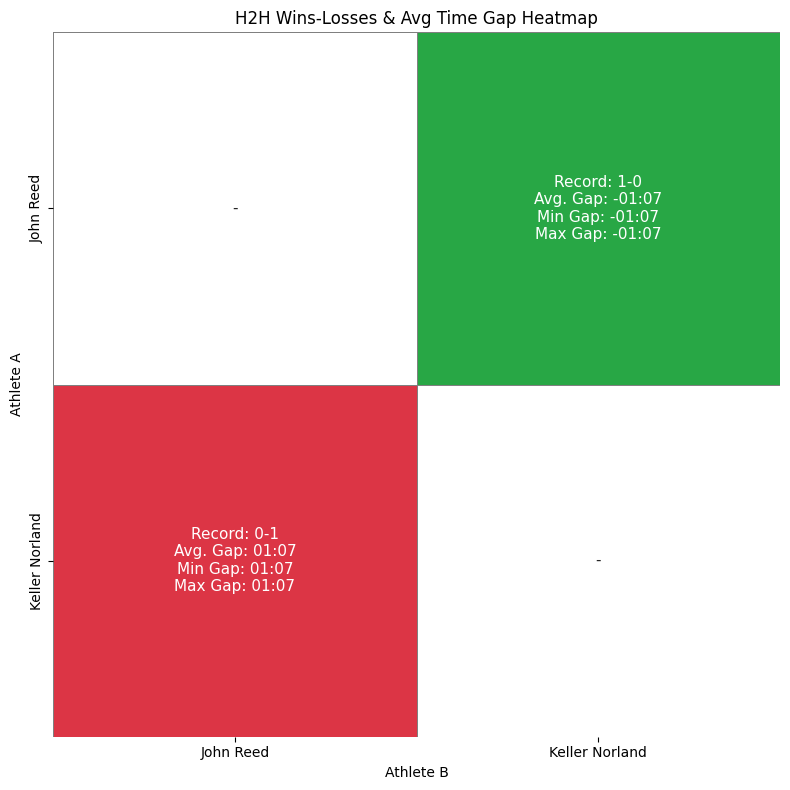

In [14]:
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Prepare the matrix and annotation matrix in a single loop
athletes = sorted(set(h2h_df['athlete_name_a']).union(h2h_df['athlete_name_b']))
matrix = pd.DataFrame('-', index=athletes, columns=athletes)
annot_matrix = pd.DataFrame('-', index=athletes, columns=athletes)
for _, row in h2h_df.iterrows():
    a = row['athlete_name_a']
    b = row['athlete_name_b']
    matches = int(row['matches'])
    wins_a = int(row['wins_a'])
    losses_a = matches - wins_a
    wins_b = int(row['wins_b'])
    losses_b = matches - wins_b
    time_gap = row['avg_time_diff'] if pd.notna(row['avg_time_diff']) else ''
    time_gap_b = '-' if pd.isna(row['avg_time_diff_sec']) else seconds_to_hms(-row['avg_time_diff_sec'])
    min_time_gap = row['min_time_diff'] if pd.notna(row['min_time_diff']) else ''
    min_time_gap_b = '-' if pd.isna(row['min_time_diff_sec']) else seconds_to_hms(-row['min_time_diff_sec'])
    max_time_gap = row['max_time_diff'] if pd.notna(row['max_time_diff']) else ''
    max_time_gap_b = '-' if pd.isna(row['max_time_diff_sec']) else seconds_to_hms(-row['max_time_diff_sec'])    
    if matches > 0:
        matrix.loc[a, b] = f"{wins_a}-{losses_a}"
        matrix.loc[b, a] = f"{wins_b}-{losses_b}"
        annot_matrix.loc[a, b] = f"Record: {wins_a}-{losses_a}\nAvg. Gap: {time_gap}"
        annot_matrix.loc[b, a] = f"Record: {wins_b}-{losses_b}\nAvg. Gap: {time_gap_b}"
        annot_matrix.loc[a, b] += f"\nMin Gap: {min_time_gap}\nMax Gap: {max_time_gap}"
        annot_matrix.loc[b, a] += f"\nMin Gap: {min_time_gap_b}\nMax Gap: {max_time_gap_b}"
for name in athletes:
    matrix.loc[name, name] = '-'
    annot_matrix.loc[name, name] = '-'


def color_code(val):
    if val == '-':
        return 0  # white for default/diagonal
    if not isinstance(val, str) or '-' not in val:
        return 0
    wins, losses = val.split('-')[0:2]
    if not (wins.isdigit() and losses.isdigit()):
        return 0
    wins, losses = int(wins), int(losses)
    if wins > losses:
        return 1  # green
    elif wins < losses:
        return -1  # red
    else:
        return 0  # white for tie
z = matrix.applymap(color_code).values
from matplotlib.colors import ListedColormap, BoundaryNorm
cmap = ListedColormap(['#dc3545', 'white', '#28a745'])  # red, white, green
bounds = [-1.5, -0.5, 0.5, 1.5]
norm = BoundaryNorm(bounds, cmap.N)

# --- Error handling for empty data ---
if len(athletes) == 0 or h2h_df.empty:
    print("No head-to-head data available for the selected athletes and events. Please adjust your selection and try again.")
else:
    plt.figure(figsize=(8,8))
    ax = sns.heatmap(z, annot=annot_matrix.values, fmt='', cmap=cmap, norm=norm,
                     cbar=False, xticklabels=athletes, yticklabels=athletes,
                     linewidths=0.5, linecolor='gray', annot_kws={"size":11})
    plt.title('H2H Wins-Losses & Avg Time Gap Heatmap')
    plt.xlabel('Athlete B')
    plt.ylabel('Athlete A')
    plt.tight_layout()
    output_dir = 'outputs'
    os.makedirs(output_dir, exist_ok=True)
    overall_path2 = os.path.join(output_dir, 'h2h_overall_heatmap_with_timegap.png')
    plt.savefig(overall_path2, dpi=300, bbox_inches='tight')
    print(f"Saved overall H2H heatmap with time gap to {overall_path2}")
    plt.show()


In [16]:
 f"Record: {wins_a}-{losses_a}\nAvg. Gap: {time_gap}"
        annot_matrix.loc[b, a] = f"Record: {wins_b}-{losses_b}\nAvg. Gap: {time_gap_b}"
        annot_matrix.loc[a, b] += f"\nMin Gap: {min_time_gap}\nMax Gap: {max_time_gap}"
        annot_matrix.loc[b, a] += f"\nMin Gap: {min_time_gap_b}\nMax Gap: {max_time_gap_b}"
for name in athletes:
    matrix.loc[name, name] = '-'
    annot_matrix.loc[name, name] = '-'

def color_code(val):
    if val == '-':
        return 0  # white for default/diagonal
    if not isinstance(val, str) or '-' not in val:
        return 0
    wins, losses = val.split('-')[0:2]
    if not (wins.isdigit() and losses.isdigit()):
        return 0
    wins, losses = int(wins), int(losses)
    if wins > losses:
        return 1  # green
    elif wins < losses:
        return -1  # red
    else:
        return 0  # white for tie
z = matrix.applymap(color_code).values
from matplotlib.colors import ListedColormap, BoundaryNorm
cmap = ListedColormap(['#dc3545', 'white', '#28a745'])  # red, white, green
bounds = [-1.5, -0.5, 0.5, 1.5]
norm = BoundaryNorm(bounds, cmap.N)

plt.figure(figsize=(8,8))
ax = sns.heatmap(z, annot=annot_matrix.values, fmt='', cmap=cmap, norm=norm,
                 cbar=False, xticklabels=athletes, yticklabels=athletes,
                 linewidths=0.5, linecolor='gray', annot_kws={"size":11})
plt.title('H2H Wins-Losses & Avg Time Gap Heatmap')
plt.xlabel('Athlete B')
plt.ylabel('Athlete A')
plt.tight_layout()
output_dir = 'outputs'
os.makedirs(output_dir, exist_ok=True)
overall_path2 = os.path.join(output_dir, 'h2h_overall_heatmap_with_timegap.png')
plt.savefig(overall_path2, dpi=300, bbox_inches='tight')
print(f"Saved overall H2H heatmap with time gap to {overall_path2}")
plt.show()


IndentationError: unexpected indent (2605100899.py, line 1)

C:\Users\jhigh\AppData\Local\Temp\ipykernel_27388\4132805027.py:21: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  z = matrix.applymap(color_code).values


Saved heatmap to outputs/h2h_swim_heatmap.png


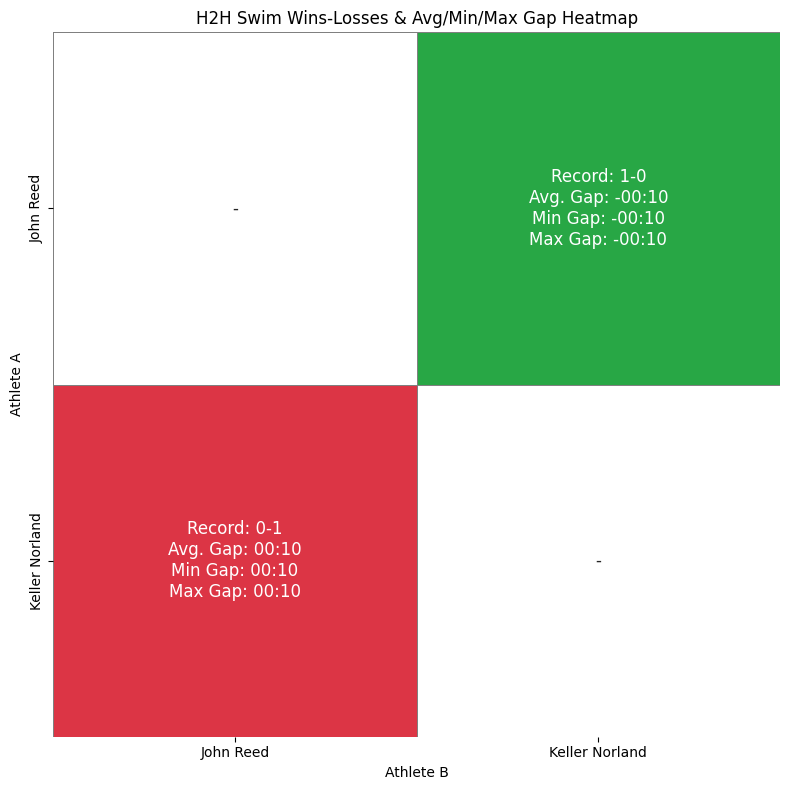

Saved heatmap to outputs/h2h_t1_heatmap.png


C:\Users\jhigh\AppData\Local\Temp\ipykernel_27388\4132805027.py:21: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  z = matrix.applymap(color_code).values


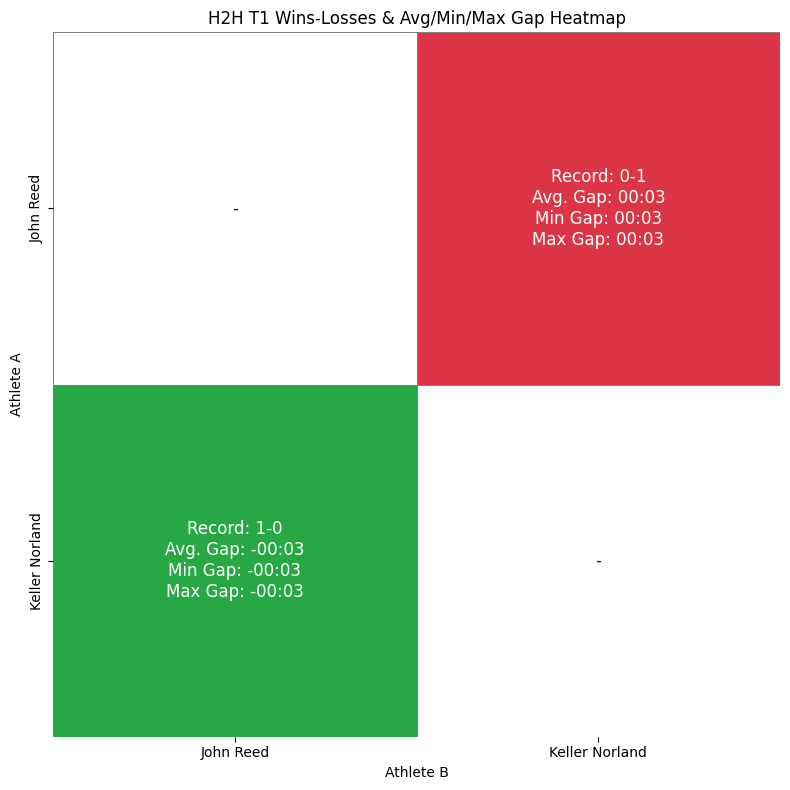

C:\Users\jhigh\AppData\Local\Temp\ipykernel_27388\4132805027.py:21: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  z = matrix.applymap(color_code).values


Saved heatmap to outputs/h2h_bike_heatmap.png


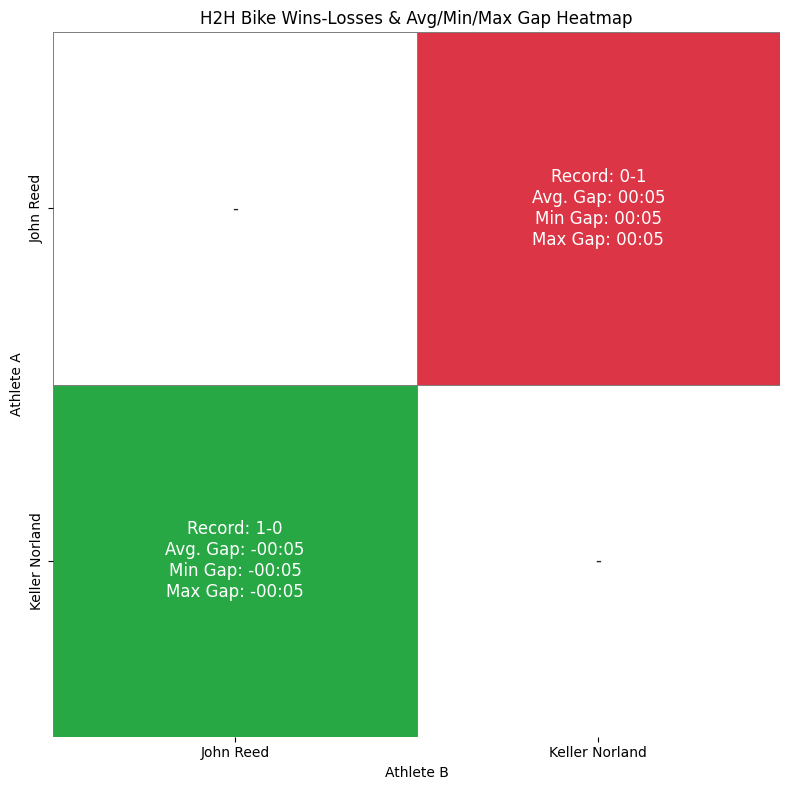

C:\Users\jhigh\AppData\Local\Temp\ipykernel_27388\4132805027.py:21: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  z = matrix.applymap(color_code).values


Saved heatmap to outputs/h2h_t2_heatmap.png


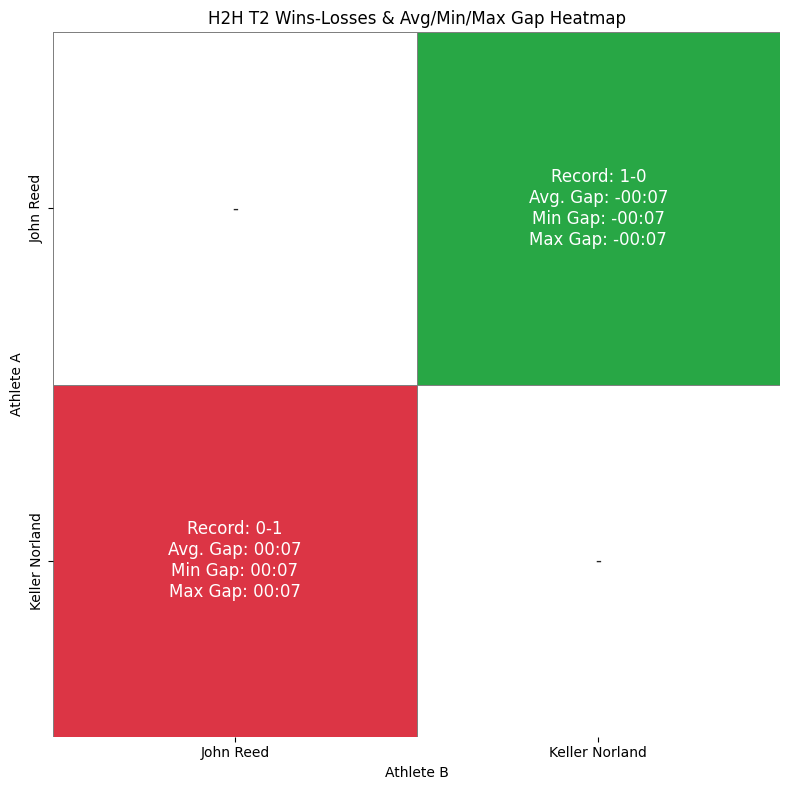

C:\Users\jhigh\AppData\Local\Temp\ipykernel_27388\4132805027.py:21: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  z = matrix.applymap(color_code).values


Saved heatmap to outputs/h2h_run_heatmap.png


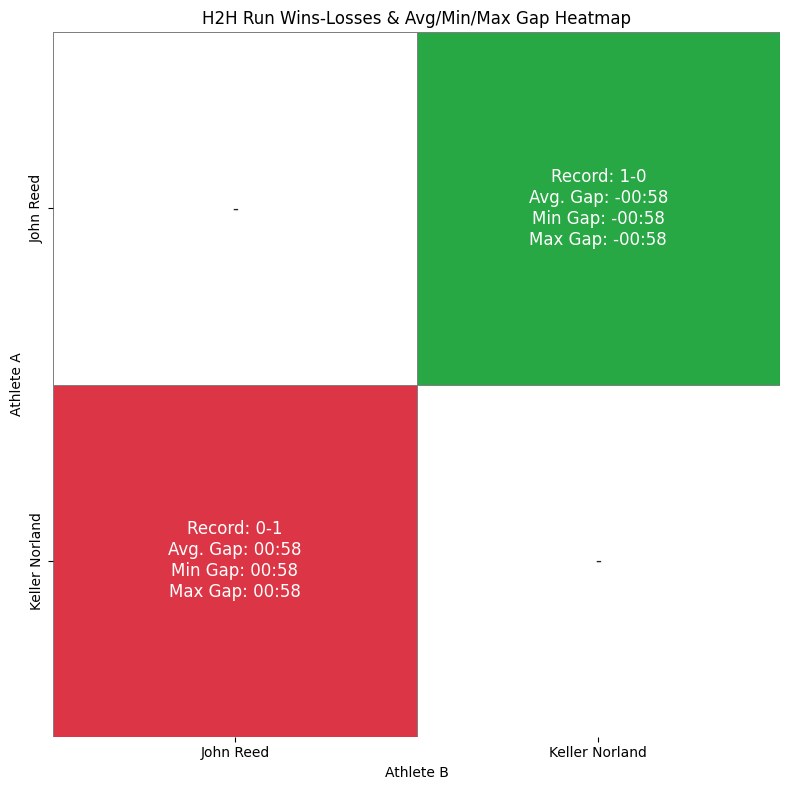

In [15]:
import os

def plot_segment_h2h(matrix, annot_matrix, segment, athletes, title_suffix="", save_path=None):
    """Plot a Seaborn heatmap for a given segment (swim, t1, bike, t2, run) H2H matrix with avg/min/max time gap annotation.
    If save_path is provided, saves the figure as a PNG image."""
    def color_code(val):
        if val == '-':
            return 0  # white for default/diagonal
        if not isinstance(val, str) or '-' not in val:
            return 0
        wins, losses = val.split('-')
        if not (wins.isdigit() and losses.isdigit()):
            return 0
        wins, losses = int(wins), int(losses)
        if wins > losses:
            return 1  # green
        elif wins < losses:
            return -1  # red
        else:
            return 0  # white for tie
    z = matrix.applymap(color_code).values
    from matplotlib.colors import ListedColormap, BoundaryNorm
    cmap = ListedColormap(['#dc3545', 'white', '#28a745'])  # red, white, green
    bounds = [-1.5, -0.5, 0.5, 1.5]
    norm = BoundaryNorm(bounds, cmap.N)
    plt.figure(figsize=(8,8))
    ax = sns.heatmap(z, annot=annot_matrix.values, fmt='', cmap=cmap, norm=norm,
                     cbar=False, xticklabels=athletes, yticklabels=athletes,
                     linewidths=0.5, linecolor='gray', annot_kws={"size":12})
    plt.title(f'H2H {segment.capitalize()} Wins-Losses & Avg/Min/Max Gap Heatmap' + (f' {title_suffix}' if title_suffix else ''))
    plt.xlabel('Athlete B')
    plt.ylabel('Athlete A')
    plt.tight_layout()
    if save_path:
        # Ensure output directory exists
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved heatmap to {save_path}")
    plt.show()

# Helper to build segment matrix and annotation matrix with min/max gap
def build_segment_matrix(h2h_df, segment, athletes):
    matrix = pd.DataFrame('-', index=athletes, columns=athletes)
    annot_matrix = pd.DataFrame('-', index=athletes, columns=athletes)
    wins_col = f'{segment}_wins_a'
    matches_col = 'matches'
    # Map segment to correct avg/min/max diff column names in h2h_df
    seg_to_col = {
        'swim': ('avg_swimtime_sec_diff_fmt', 'min_swimtime_sec_diff_fmt', 'max_swimtime_sec_diff_fmt'),
        't1':   ('avg_t1time_sec_diff_fmt',   'min_t1time_sec_diff_fmt',   'max_t1time_sec_diff_fmt'),
        'bike': ('avg_biketime_sec_diff_fmt', 'min_biketime_sec_diff_fmt', 'max_biketime_sec_diff_fmt'),
        't2':   ('avg_t2time_sec_diff_fmt',   'min_t2time_sec_diff_fmt',   'max_t2time_sec_diff_fmt'),
        'run':  ('avg_runtime_sec_diff_fmt',  'min_runtime_sec_diff_fmt',  'max_runtime_sec_diff_fmt'),
    }
    avg_gap_col, min_gap_col, max_gap_col = seg_to_col.get(segment, (None, None, None))
    for _, row in h2h_df.iterrows():
        a = row['athlete_name_a']
        b = row['athlete_name_b']
        matches = int(row[matches_col])
        wins_a = int(row[wins_col]) if pd.notna(row[wins_col]) else 0
        losses_a = matches - wins_a
        wins_b = matches - wins_a
        losses_b = matches - wins_b
        avg_gap = row[avg_gap_col] if avg_gap_col in row and pd.notna(row[avg_gap_col]) else ''
        min_gap = row[min_gap_col] if min_gap_col in row and pd.notna(row[min_gap_col]) else ''
        max_gap = row[max_gap_col] if max_gap_col in row and pd.notna(row[max_gap_col]) else ''
        # For B vs A, flip sign for avg/min/max gap if not empty and not already negative
        def flip_gap(gap):
            if not gap or gap == '-' or gap == '00:00:00': return gap
            return ('-' + gap) if gap[0] != '-' else gap.replace('-', '')
        avg_gap_b = flip_gap(avg_gap)
        min_gap_b = flip_gap(min_gap)
        max_gap_b = flip_gap(max_gap)
        matrix.loc[a, b] = f"{wins_a}-{losses_a}" if matches > 0 else '-'
        matrix.loc[b, a] = f"{wins_b}-{losses_b}" if matches > 0 else '-'
        if matches > 0:
            annot_matrix.loc[a, b] = f"Record: {wins_a}-{losses_a}\nAvg. Gap: {avg_gap}\nMin Gap: {min_gap}\nMax Gap: {max_gap}"
            annot_matrix.loc[b, a] = f"Record: {wins_b}-{losses_b}\nAvg. Gap: {avg_gap_b}\nMin Gap: {min_gap_b}\nMax Gap: {max_gap_b}"
    for name in athletes:
        matrix.loc[name, name] = '-'
        annot_matrix.loc[name, name] = '-'
    return matrix, annot_matrix

# Generate and plot for each segment, saving PNGs
segments = ['swim', 't1', 'bike', 't2', 'run']
athletes = sorted(set(h2h_df['athlete_name_a']).union(h2h_df['athlete_name_b']))
output_dir = 'outputs'
for segment in segments:
    seg_matrix, seg_annot = build_segment_matrix(h2h_df, segment, athletes)
    filename = f"{output_dir}/h2h_{segment}_heatmap.png"
    plot_segment_h2h(seg_matrix, seg_annot, segment, athletes, save_path=filename)


# Visualization & Sharing Plan


To build on our head-to-head matrix and deliver shareable charts, we can follow this roadmap:


1. Modular Data & Plotting Functions


   - **Data extraction**: A single function that takes `selected_athletes` and `selected_events` and returns filtered `h2h_df` with all metrics.  

   - **Matrix plot**: A plotting function that accepts `h2h_df` and outputs:

     - A **heatmap** of wins-losses (or win percentages) using Plotly or Seaborn.

     - Exports as interactive HTML (for web) or static image (for reports).


   - **Segment charts**: A function that creates bar/line charts for swim, T1, bike, T2, run H2H records by pair or aggregate.  

2. Choice of Libraries


   - **Plotly** for interactive, zoomable charts and easy export to HTML.

   - **Seaborn/Matplotlib** for quick static images (PNGs) that can be embedded in PowerPoint or PDFs.

   - **Pandas Styler** or **Dash/Voila** if we need a polished dashboard.

3. Interactive Dashboard / Notebook Workflow


   - **Widgets** drive `selected_athletes` and `selected_events`.

   - After selection, call data and plotting functions in one cell.

   - Display interactive charts inline or launch a small app (Dash/Panel) for management to explore.

4. Sharing & Storage


   - **HTML exports**: Chart + data in one file, easy to email or host.

   - **Static exports**: Save figures as PNG/SVG in an `outputs/` directory.

   - **PowerPoint integration**: Use Python-PPTX to automate slide creation once images are generated.

5. Scalability & Maintenance


   - Parameterize functions so changing athlete/event lists or adding new metric types (e.g., segment H2H) is just a function call.

   - Document each function with docstrings and examples.

   - Store favorites or presets (e.g., default teams) in a small config file or cell.

6. Next Steps


   - Prototype the matrix heatmap with Plotly for one athlete pair set.

   - Build segment H2H bar charts.

   - Experiment with exporting to HTML and PNG.

   - Review with management and iterate on presentation format.